# M1 — The VP-linear noise schedule

Everything in this project is built on one continuous-time forward process. This
notebook defines it, plots it, and checks the identities the solvers rely on.

**What it establishes**

- `alpha(t)`, `sigma(t)` with `alpha**2 + sigma**2 = 1` (variance preserving)
- the PF-ODE coefficients `f(t) = d log alpha/dt = -beta(t)/2` and `g2(t) = beta(t)`
- the half log-SNR `lambda(t) = log alpha - log sigma`, **strictly decreasing in t**,
  and its inverse `t_of_lmbda`
- the lambda-domain coefficients `alpha_hat`, `sigma_hat` used by arm B and arm C

Constants match the base paper: `beta_0 = 0.1`, `beta_1 = 20`, `T = 1`.

In [1]:
import sys, pathlib, subprocess
import numpy as np
import matplotlib.pyplot as plt

# --- make `src` importable from anywhere in the repo ---
p = pathlib.Path.cwd()
while not (p / "pyproject.toml").exists() and p != p.parent:
    p = p.parent
ROOT = p
sys.path.insert(0, str(ROOT))

from src.schedule import (
    BETA_0, BETA_1, T_MAX,
    log_alpha, alpha, beta, f, g2, sigma, lmbda, t_of_lmbda, alpha_hat, sigma_hat,
)

FIGDIR = ROOT / "figures"
FIGDIR.mkdir(exist_ok=True)
print(f"repo root: {ROOT}")
print(f"beta_0={BETA_0}  beta_1={BETA_1}  T={T_MAX}")

repo root: /Users/mehemudazad/Desktop/buet-4.1/CSE-402/numerical-project
beta_0=0.1  beta_1=20.0  T=1.0


## 1. Signal and noise levels

$$\log\alpha(t) = -\tfrac{\beta_1-\beta_0}{4}t^2 - \tfrac{\beta_0}{2}t,
\qquad \sigma(t) = \sqrt{1-\alpha(t)^2}.$$

`t` runs from `T = 1` (pure noise: `alpha` tiny, `sigma ~ 1`) down to `t_end ~ 1e-3`
(mostly signal).

alpha(1)   = 6.571586e-03   sigma(1)   = 0.999978
alpha(1e-3)= 0.999945   sigma(1e-3)= 1.048542e-02
max |alpha^2 + sigma^2 - 1| = 2.22e-16


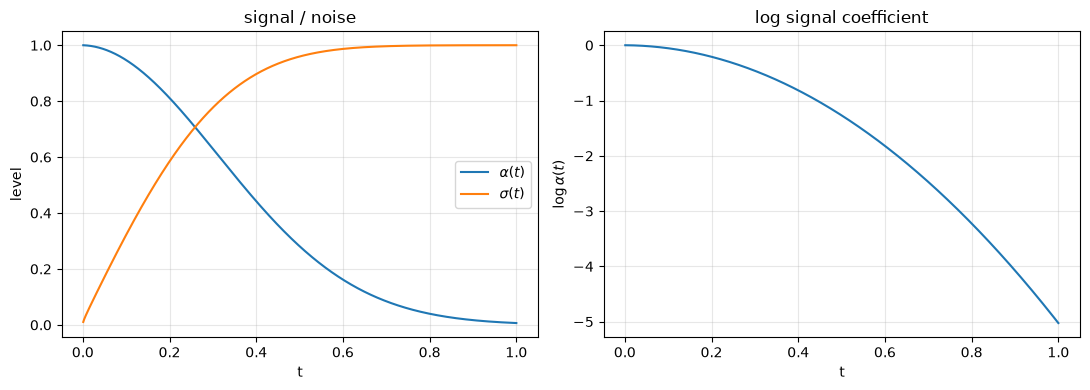

In [2]:
T_END = 1e-3
t = np.linspace(T_END, T_MAX, 1000)

a, s, la = alpha(t), sigma(t), log_alpha(t)
print(f"alpha(1)   = {alpha(1.0):.6e}   sigma(1)   = {sigma(1.0):.6f}")
print(f"alpha(1e-3)= {alpha(T_END):.6f}   sigma(1e-3)= {sigma(T_END):.6e}")
print(f"max |alpha^2 + sigma^2 - 1| = {np.abs(a**2 + s**2 - 1.0).max():.2e}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(t, a, label=r"$\alpha(t)$")
ax[0].plot(t, s, label=r"$\sigma(t)$")
ax[0].set_xlabel("t"); ax[0].set_ylabel("level"); ax[0].legend(); ax[0].set_title("signal / noise")
ax[1].plot(t, la)
ax[1].set_xlabel("t"); ax[1].set_ylabel(r"$\log\alpha(t)$"); ax[1].set_title("log signal coefficient")
for x in ax: x.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 2. PF-ODE coefficients

$$\beta(t) = \beta_0 + t(\beta_1-\beta_0),\qquad
f(t) = \frac{d\log\alpha}{dt} = -\tfrac12\beta(t),\qquad g^2(t) = \beta(t).$$

`f` is the stiff linear drift DPM-Solver handles exactly; `g2` scales the score term.

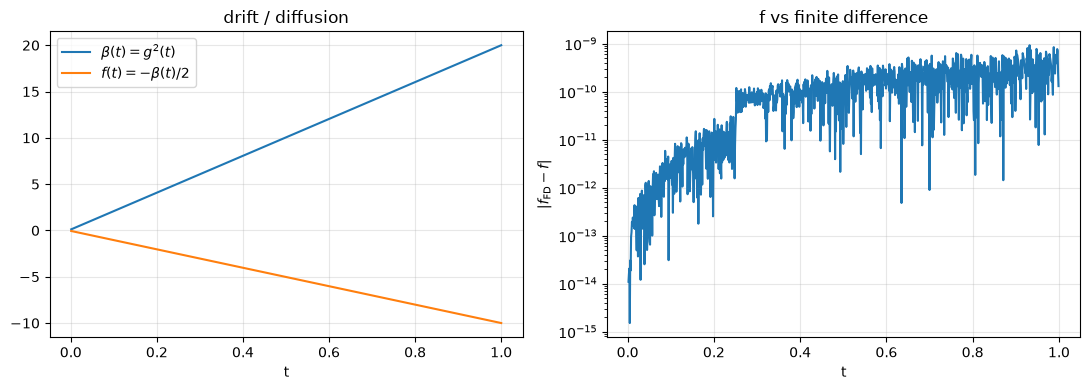

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(t, beta(t), label=r"$\beta(t)=g^2(t)$")
ax[0].plot(t, f(t), label=r"$f(t)=-\beta(t)/2$")
ax[0].set_xlabel("t"); ax[0].legend(); ax[0].set_title("drift / diffusion")

# check f against a central finite difference of log_alpha
dt = 1e-6
fd = (log_alpha(t[1:-1] + dt) - log_alpha(t[1:-1] - dt)) / (2 * dt)
ax[1].semilogy(t[1:-1], np.abs(fd - f(t[1:-1])) + 1e-300)
ax[1].set_xlabel("t"); ax[1].set_ylabel(r"$|f_{\rm FD} - f|$"); ax[1].set_title("f vs finite difference")
for x in ax: x.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 3. The half log-SNR $\lambda(t)$ — the good time variable

$$\lambda(t) = \log\alpha(t) - \log\sigma(t).$$

$\lambda$ is **strictly decreasing in $t$**: $t=1$ gives the most negative $\lambda$,
and $\lambda\to+\infty$ as $t\to 0$. Arm B and arm C step uniformly in $\lambda$.
Getting this direction backwards is the most common bug in the project, so we check it.

lambda(1)    = -5.0250   (most negative)
lambda(1e-3) = +4.5577
lambda(1e-5) = +6.9073   (-> +inf as t -> 0)


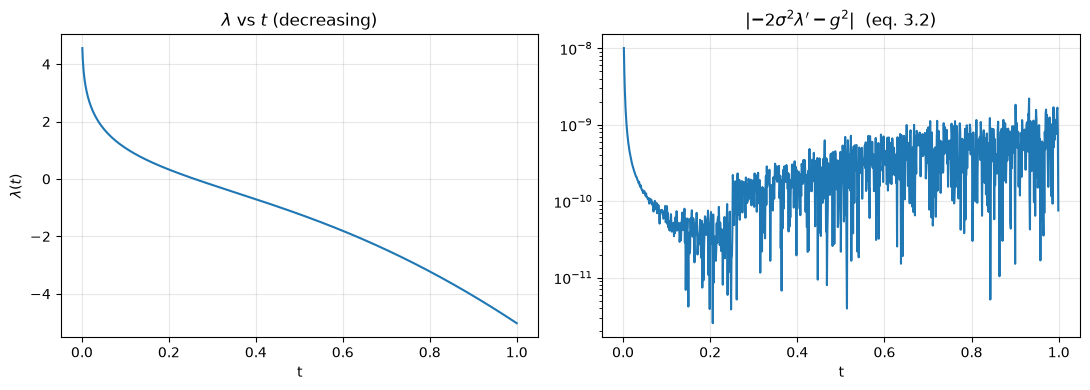

In [4]:
lam = lmbda(t)
assert np.all(np.diff(lam) < 0), "lambda must strictly decrease in t"
print(f"lambda(1)    = {lmbda(1.0):+.4f}   (most negative)")
print(f"lambda(1e-3) = {lmbda(T_END):+.4f}")
print(f"lambda(1e-5) = {lmbda(1e-5):+.4f}   (-> +inf as t -> 0)")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(t, lam)
ax[0].set_xlabel("t"); ax[0].set_ylabel(r"$\lambda(t)$"); ax[0].set_title(r"$\lambda$ vs $t$ (decreasing)")

# g^2(t) = -2 sigma(t)^2 dlambda/dt   (paper eq. 3.2)
tc = t[1:-1]
dl = (lmbda(tc + dt) - lmbda(tc - dt)) / (2 * dt)
ax[1].semilogy(tc, np.abs(-2 * sigma(tc) ** 2 * dl - g2(tc)) + 1e-300)
ax[1].set_xlabel("t"); ax[1].set_title(r"$|{-2\sigma^2 \lambda'} - g^2|$  (eq. 3.2)")
for x in ax: x.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 4. The inverse $t(\lambda)$

Solving $-2\log\alpha(t) = \log(1+e^{-2\lambda})$ for $t$ (a quadratic) gives the
cancellation-free form

$$t(\lambda) = \frac{2u}{\sqrt{\beta_0^2 + 2(\beta_1-\beta_0)u} + \beta_0},
\qquad u = \log(e^{-2\lambda}+1).$$

max relative round-trip error  t -> lambda -> t : 1.78e-15


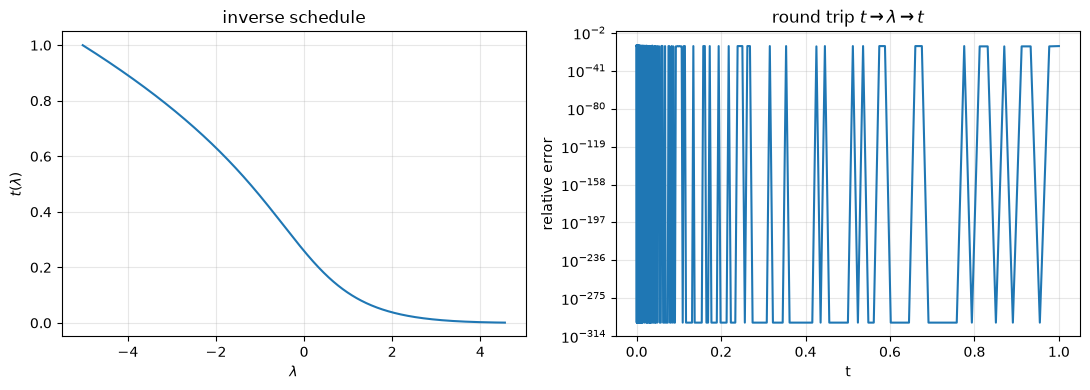

In [5]:
lam_grid = np.linspace(lmbda(T_MAX), lmbda(T_END), 1000)   # ascending in lambda
t_rec = t_of_lmbda(lam_grid)

# round trip on a log-spaced t grid
tt = np.logspace(-4, 0, 400)
rt_err = np.abs(t_of_lmbda(lmbda(tt)) / tt - 1.0)
print(f"max relative round-trip error  t -> lambda -> t : {rt_err.max():.2e}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(lam_grid, t_rec)
ax[0].set_xlabel(r"$\lambda$"); ax[0].set_ylabel(r"$t(\lambda)$"); ax[0].set_title("inverse schedule")
ax[1].semilogy(tt, rt_err + 1e-300)
ax[1].set_xlabel("t"); ax[1].set_ylabel("relative error"); ax[1].set_title(r"round trip $t\to\lambda\to t$")
for x in ax: x.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 5. Lambda-domain coefficients

$$\hat\alpha(\lambda) = \frac{1}{\sqrt{1+e^{-2\lambda}}} = \alpha(t(\lambda)),
\qquad
\hat\sigma(\lambda) = \frac{1}{\sqrt{1+e^{2\lambda}}} = \sigma(t(\lambda)).$$

These let arm B write its ODE directly in $\lambda$ without round-tripping through $t$.

In [6]:
err_a = np.abs(alpha_hat(lam) - alpha(t)).max()
err_s = np.abs(sigma_hat(lam) - sigma(t)).max()
err_1 = np.abs(alpha_hat(lam) ** 2 + sigma_hat(lam) ** 2 - 1.0).max()
print(f"max |alpha_hat(lambda(t)) - alpha(t)| = {err_a:.2e}")
print(f"max |sigma_hat(lambda(t)) - sigma(t)| = {err_s:.2e}")
print(f"max |alpha_hat^2 + sigma_hat^2 - 1|   = {err_1:.2e}")

max |alpha_hat(lambda(t)) - alpha(t)| = 2.22e-16
max |sigma_hat(lambda(t)) - sigma(t)| = 2.22e-16
max |alpha_hat^2 + sigma_hat^2 - 1|   = 4.44e-16


## 6. Summary figure (saved to `figures/01_noise_schedule.png`)

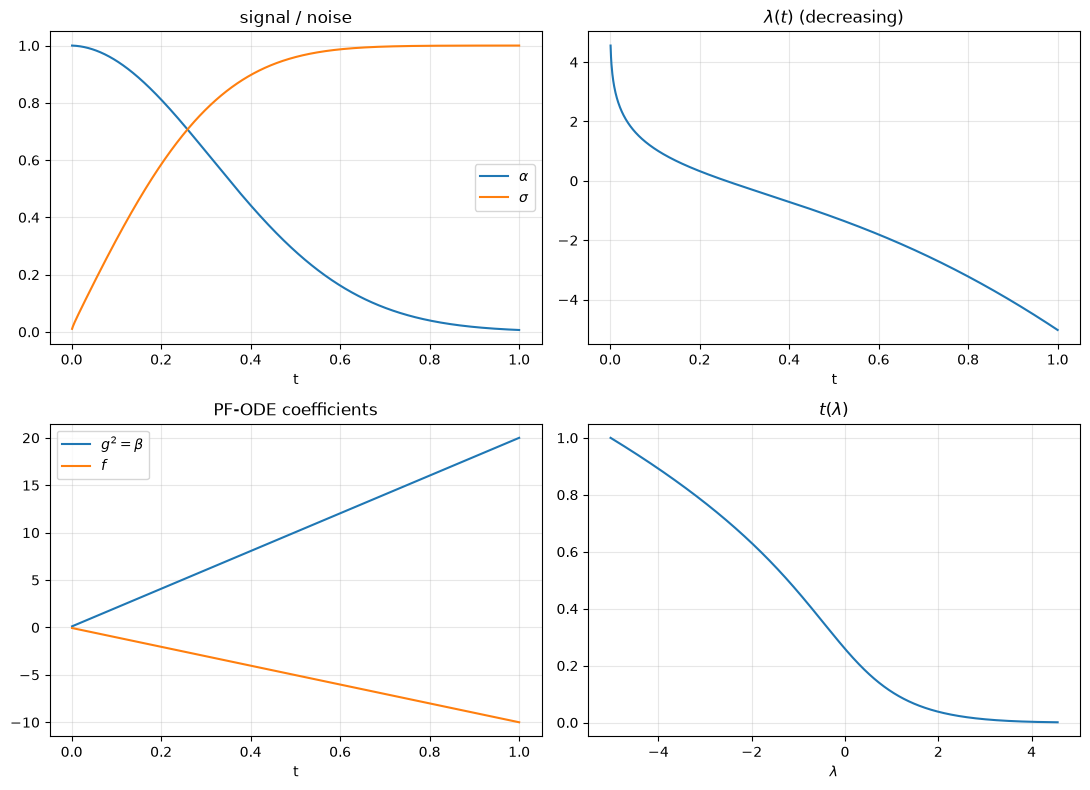

saved /Users/mehemudazad/Desktop/buet-4.1/CSE-402/numerical-project/figures/01_noise_schedule.png


In [7]:
fig, ax = plt.subplots(2, 2, figsize=(11, 8))
ax[0, 0].plot(t, a, label=r"$\alpha$"); ax[0, 0].plot(t, s, label=r"$\sigma$")
ax[0, 0].legend(); ax[0, 0].set_title("signal / noise"); ax[0, 0].set_xlabel("t")
ax[0, 1].plot(t, lam); ax[0, 1].set_title(r"$\lambda(t)$ (decreasing)"); ax[0, 1].set_xlabel("t")
ax[1, 0].plot(t, beta(t), label=r"$g^2=\beta$"); ax[1, 0].plot(t, f(t), label=r"$f$")
ax[1, 0].legend(); ax[1, 0].set_title("PF-ODE coefficients"); ax[1, 0].set_xlabel("t")
ax[1, 1].plot(lam_grid, t_rec); ax[1, 1].set_title(r"$t(\lambda)$"); ax[1, 1].set_xlabel(r"$\lambda$")
for row in ax:
    for x in row: x.grid(alpha=.3)
plt.tight_layout()
plt.savefig(FIGDIR / "01_noise_schedule.png", dpi=120)
plt.show()
print("saved", FIGDIR / "01_noise_schedule.png")

## 7. Validation — run the unit tests

`tests/test_schedule.py`: round-trip, variance preserving, `f` vs finite difference,
the `g^2` identity (eq. 3.2), the $\lambda$-direction guard, `alpha_hat`/`sigma_hat`
consistency, and agreement with the vendored `NoiseScheduleVP` (arm C depends on it).

In [8]:
out = subprocess.run(
    [sys.executable, "-m", "pytest", "tests/test_schedule.py", "-q"],
    cwd=ROOT, capture_output=True, text=True,
)
print(out.stdout)
print(out.stderr)
assert out.returncode == 0, "schedule tests failed"
print("M1 validation: PASS")

.......                                                                  [100%]


M1 validation: PASS
